<a href="https://www.kaggle.com/code/sonawanelalitsunil/employee-productivity-ml-96-12?scriptVersionId=264627435" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/employee-productivity/employee_productivity.csv


## Title: Employee Productivity

## Description:
Employee productivity refers to the efficiency and effectiveness with which employees complete their tasks and contribute to organizational goals. It is often measured by the output produced in relation to the time, resources, and effort invested. Higher productivity indicates that employees are working smarter, delivering more value within the same or less time. Factors influencing productivity include skills, training, motivation, workplace environment, tools and technology, leadership style, and work-life balance. Organizations often track productivity to identify strengths, areas for improvement, and opportunities to optimize processes. By enhancing productivity, businesses can improve profitability, employee satisfaction, and long-term growth.

## Import dataset

In [2]:
df= pd.read_csv("/kaggle/input/employee-productivity/employee_productivity.csv")

In [3]:
df.head()

,Employee_ID,Department,Experience_Years,Technical_Skill_Score,Communication_Score,Training_Hours,Projects_Completed,Avg_Weekly_Work_Hours,Productivity_Score,Salary_USD
0,E001,Data Science,5,92,85,120,18,42,88,85000
1,E002,Machine Learning,3,89,78,90,15,45,82,78000
2,E003,Data Analysis,2,75,80,70,10,40,76,62000
3,E004,Data Engineering,6,95,88,150,22,44,91,92000
4,E005,BI & Analytics,4,82,90,110,16,41,85,78000


In [4]:
df.tail()

,Employee_ID,Department,Experience_Years,Technical_Skill_Score,Communication_Score,Training_Hours,Projects_Completed,Avg_Weekly_Work_Hours,Productivity_Score,Salary_USD
5,E006,Data Science,1,70,75,60,8,38,70,55000
6,E007,Machine Learning,7,96,84,160,25,46,93,98000
7,E008,Data Engineering,3,85,79,100,14,43,81,76000
8,E009,BI & Analytics,5,87,92,130,19,40,88,83000
9,E010,Data Science,4,90,86,115,17,42,87,87000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Employee_ID            10 non-null     object
 1   Department             10 non-null     object
 2   Experience_Years       10 non-null     int64 
 3   Technical_Skill_Score  10 non-null     int64 
 4   Communication_Score    10 non-null     int64 
 5   Training_Hours         10 non-null     int64 
 6   Projects_Completed     10 non-null     int64 
 7   Avg_Weekly_Work_Hours  10 non-null     int64 
 8   Productivity_Score     10 non-null     int64 
 9   Salary_USD             10 non-null     int64 
dtypes: int64(8), object(2)
memory usage: 932.0+ bytes


In [6]:
df.describe()

,Experience_Years,Technical_Skill_Score,Communication_Score,Training_Hours,Projects_Completed,Avg_Weekly_Work_Hours,Productivity_Score,Salary_USD
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,4.000000,86.100000,83.700000,110.500000,16.400000,42.100000,84.100000,79400.000000
std,1.825742,8.412293,5.558777,32.011283,5.103376,2.469818,7.030884,12997.435645
min,1.000000,70.000000,75.000000,60.000000,8.000000,38.000000,70.000000,55000.000000
25%,3.000000,82.750000,79.250000,92.500000,14.250000,40.250000,81.250000,76500.000000
50%,4.000000,88.000000,84.500000,112.500000,16.500000,42.000000,86.000000,80500.000000
75%,5.000000,91.500000,87.500000,127.500000,18.750000,43.750000,88.000000,86500.000000
max,7.000000,96.000000,92.000000,160.000000,25.000000,46.000000,93.000000,98000.000000


In [7]:
df.nunique()

Employee_ID              10
Department                5
Experience_Years          7
Technical_Skill_Score    10
Communication_Score      10
Training_Hours           10
Projects_Completed       10
Avg_Weekly_Work_Hours     8
Productivity_Score        9
Salary_USD                9
dtype: int64

In [8]:
df.isnull().sum()

Employee_ID              0
Department               0
Experience_Years         0
Technical_Skill_Score    0
Communication_Score      0
Training_Hours           0
Projects_Completed       0
Avg_Weekly_Work_Hours    0
Productivity_Score       0
Salary_USD               0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
df.dtypes

Employee_ID              object
Department               object
Experience_Years          int64
Technical_Skill_Score     int64
Communication_Score       int64
Training_Hours            int64
Projects_Completed        int64
Avg_Weekly_Work_Hours     int64
Productivity_Score        int64
Salary_USD                int64
dtype: object

In [11]:
df.shape

(10, 10)

In [12]:
df.columns

Index(['Employee_ID', 'Department', 'Experience_Years',
       'Technical_Skill_Score', 'Communication_Score', 'Training_Hours',
       'Projects_Completed', 'Avg_Weekly_Work_Hours', 'Productivity_Score',
       'Salary_USD'],
      dtype='object')

## Data visualizations

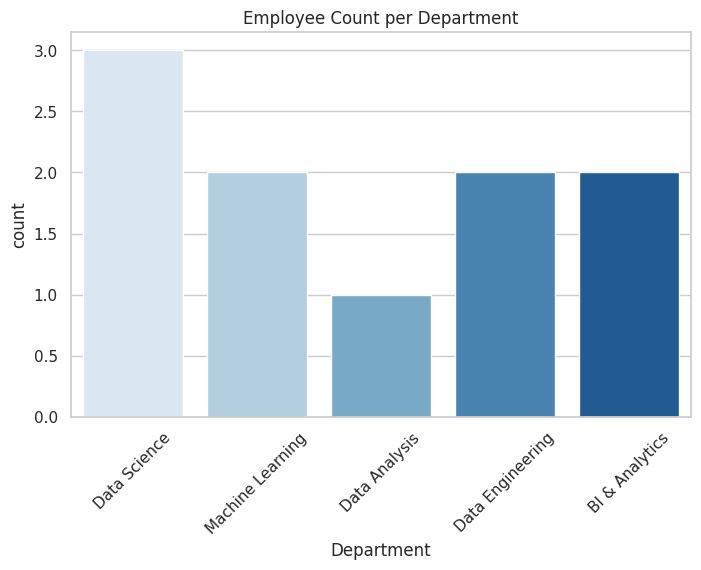

In [13]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# 1. Department-wise employee distribution
plt.figure(figsize=(8,5))
sns.countplot(x="Department", data=df, palette="Blues")
plt.title("Employee Count per Department")
plt.xticks(rotation=45)
plt.show()

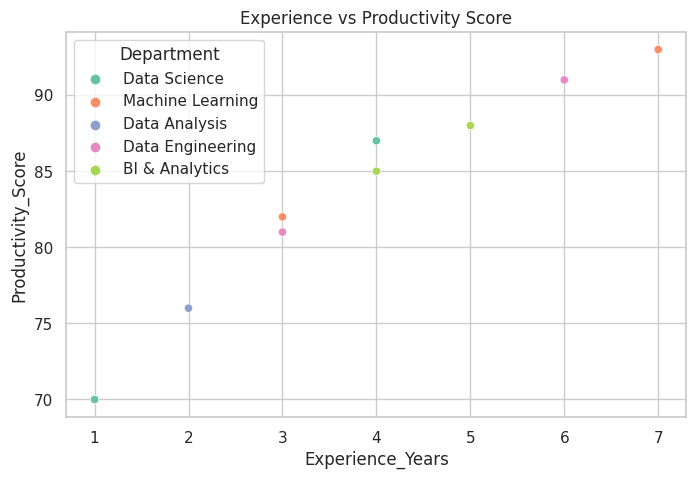

In [14]:
# 2. Experience vs Productivity
plt.figure(figsize=(8,5))
sns.scatterplot(x="Experience_Years", y="Productivity_Score", hue="Department", data=df, palette="Set2")
plt.title("Experience vs Productivity Score")
plt.show()

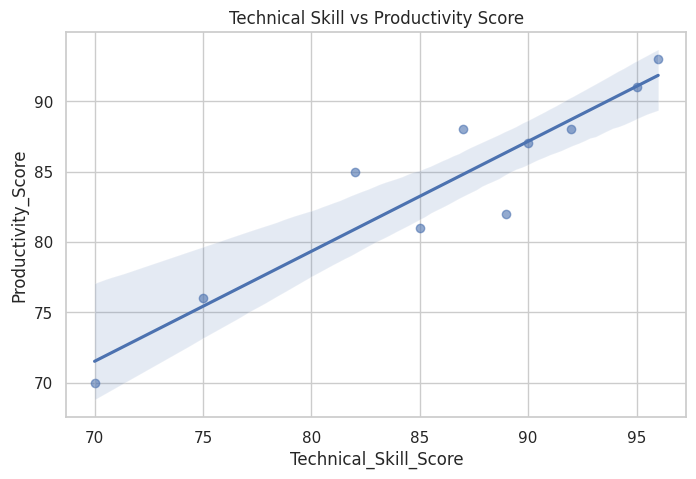

In [15]:
# 3. Technical Skill vs Productivity
plt.figure(figsize=(8,5))
sns.regplot(x="Technical_Skill_Score", y="Productivity_Score", data=df, scatter_kws={"alpha":0.6})
plt.title("Technical Skill vs Productivity Score")
plt.show()


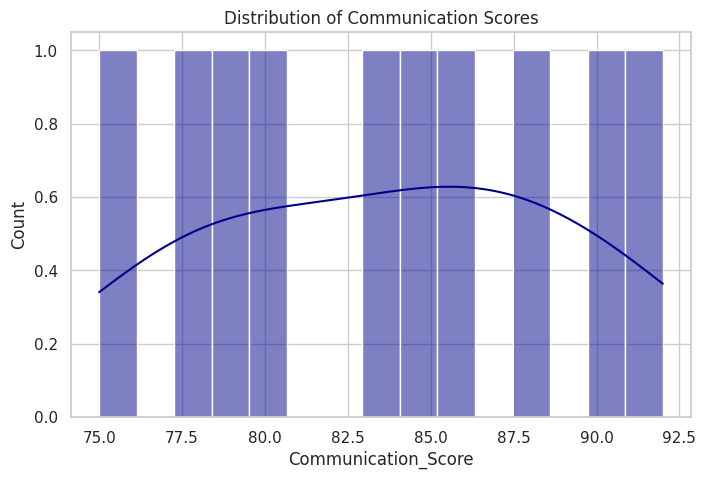

In [16]:
# 4. Communication Score distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Communication_Score"], bins=15, kde=True, color="darkblue")
plt.title("Distribution of Communication Scores")
plt.show()

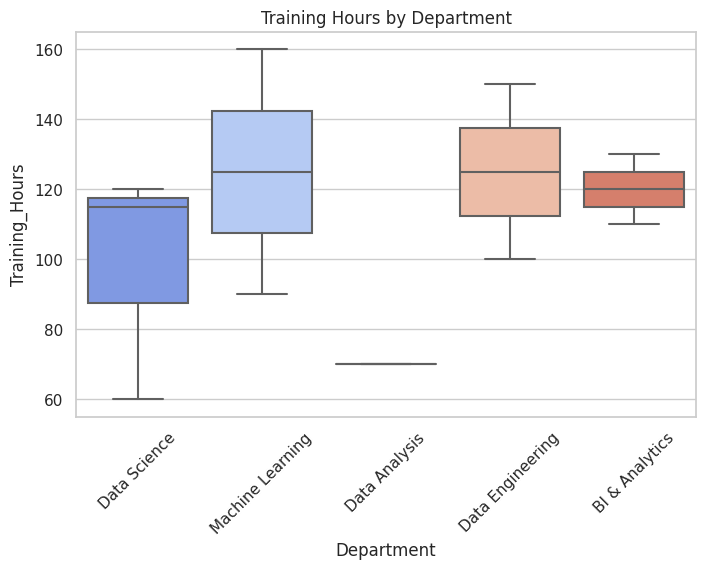

In [17]:
# 5. Training Hours by Department
plt.figure(figsize=(8,5))
sns.boxplot(x="Department", y="Training_Hours", data=df, palette="coolwarm")
plt.title("Training Hours by Department")
plt.xticks(rotation=45)
plt.show()


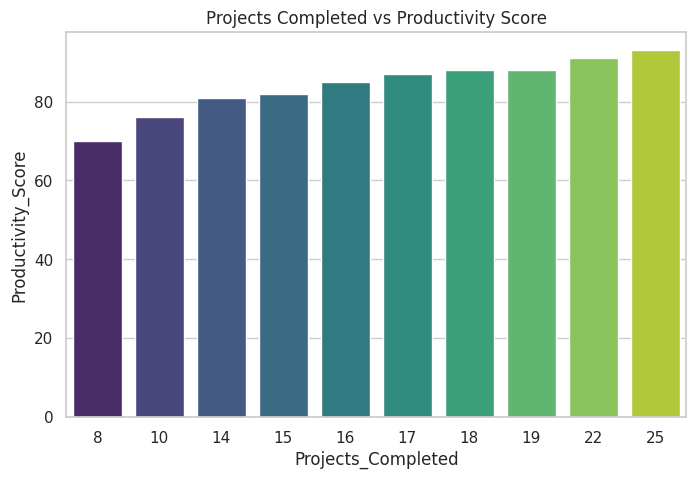

In [18]:
# 6. Projects Completed vs Productivity
plt.figure(figsize=(8,5))
sns.barplot(x="Projects_Completed", y="Productivity_Score", data=df, palette="viridis")
plt.title("Projects Completed vs Productivity Score")
plt.show()

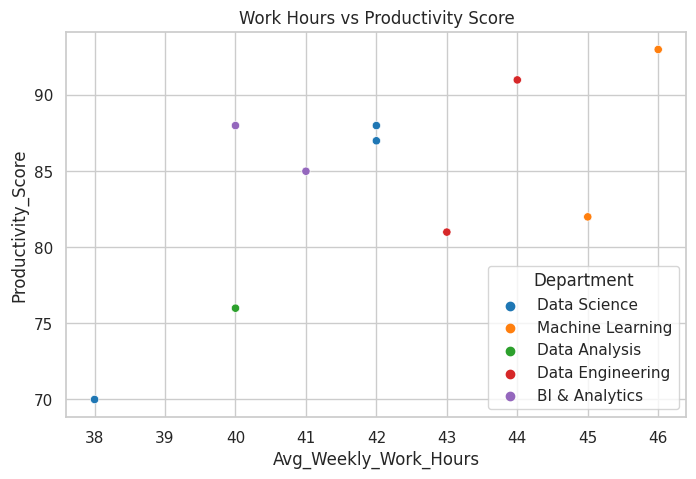

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Avg_Weekly_Work_Hours", y="Productivity_Score", hue="Department", data=df, palette="tab10")
plt.title("Work Hours vs Productivity Score")
plt.show()

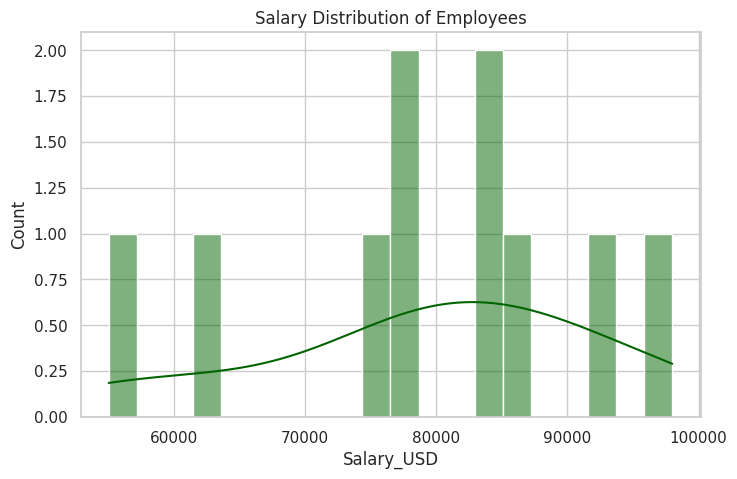

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df["Salary_USD"], bins=20, kde=True, color="darkgreen")
plt.title("Salary Distribution of Employees")
plt.show()

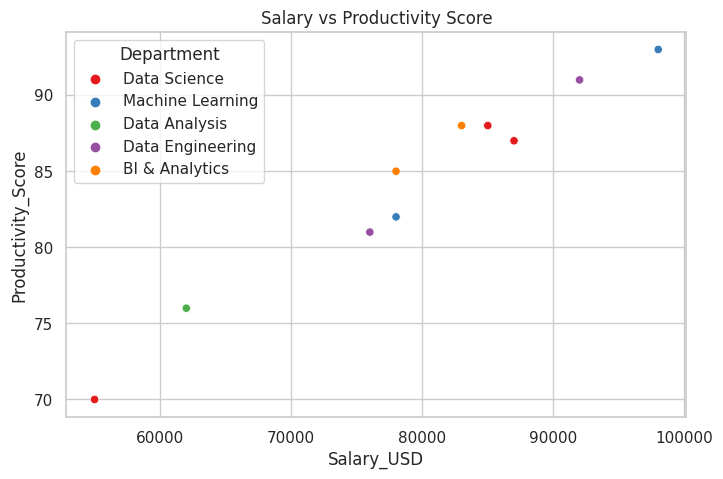

In [21]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Salary_USD", y="Productivity_Score", data=df, hue="Department", palette="Set1")
plt.title("Salary vs Productivity Score")
plt.show()

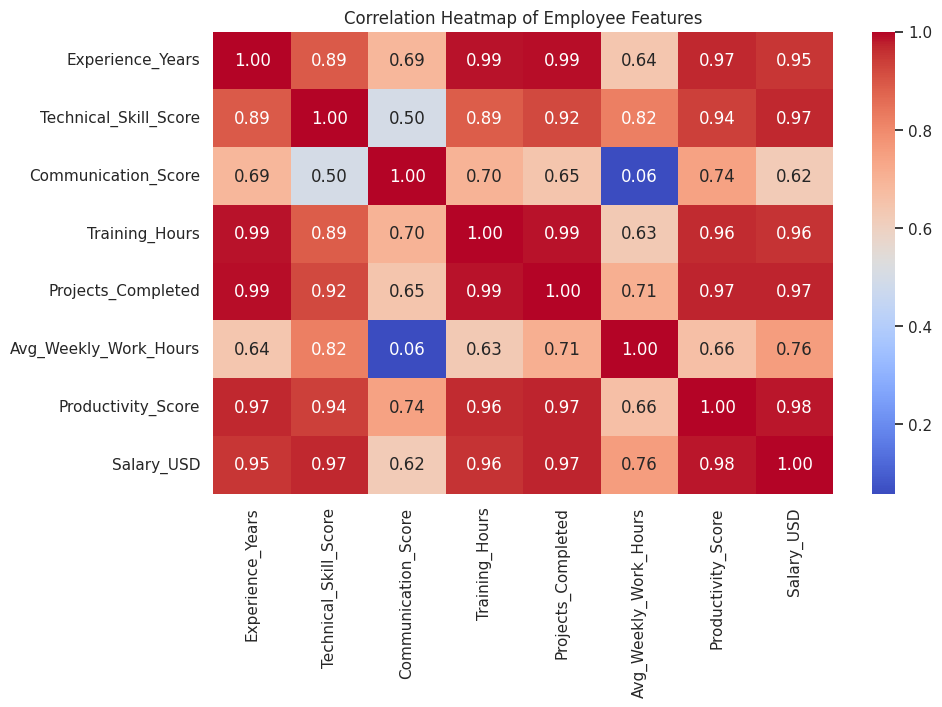

In [22]:
plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Employee Features")
plt.show()

## ML Algorithms

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

In [24]:
le = LabelEncoder()
df["Department"] = le.fit_transform(df["Department"])

In [25]:
X = df.drop(["Employee_ID", "Productivity_Score"], axis=1)
y = df["Productivity_Score"]

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "SVM": SVR(),
    "KNN": KNeighborsRegressor()
}

In [29]:
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append([name, r2*100, mae, rmse])
    print(f"{name}: R²={r2*100:.2f}%, MAE={mae:.2f}, RMSE={rmse:.2f}")

Linear Regression: R²=96.12%, MAE=0.58, RMSE=0.59
Decision Tree: R²=44.44%, MAE=2.00, RMSE=2.24
Random Forest: R²=70.60%, MAE=1.35, RMSE=1.63
Gradient Boosting: R²=87.09%, MAE=1.07, RMSE=1.08
SVM: R²=-1.73%, MAE=2.96, RMSE=3.03
KNN: R²=48.22%, MAE=2.10, RMSE=2.16


In [30]:
results_df = pd.DataFrame(results, columns=["Model", "R² (%)", "MAE", "RMSE"])

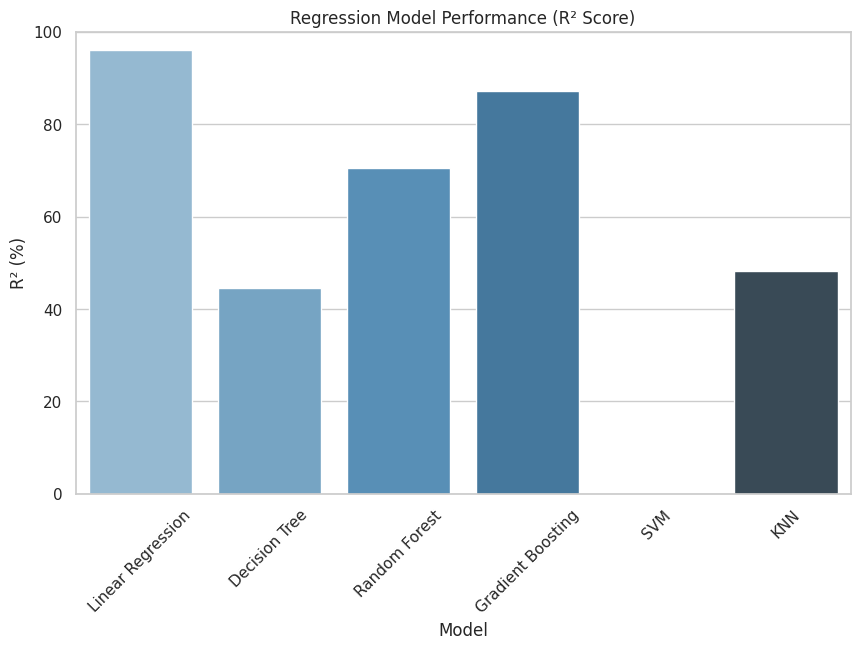

In [31]:
plt.figure(figsize=(10,6))
sns.barplot(x="Model", y="R² (%)", data=results_df, palette="Blues_d")
plt.title("Regression Model Performance (R² Score)")
plt.xticks(rotation=45)
plt.ylim(0,100)
plt.show()

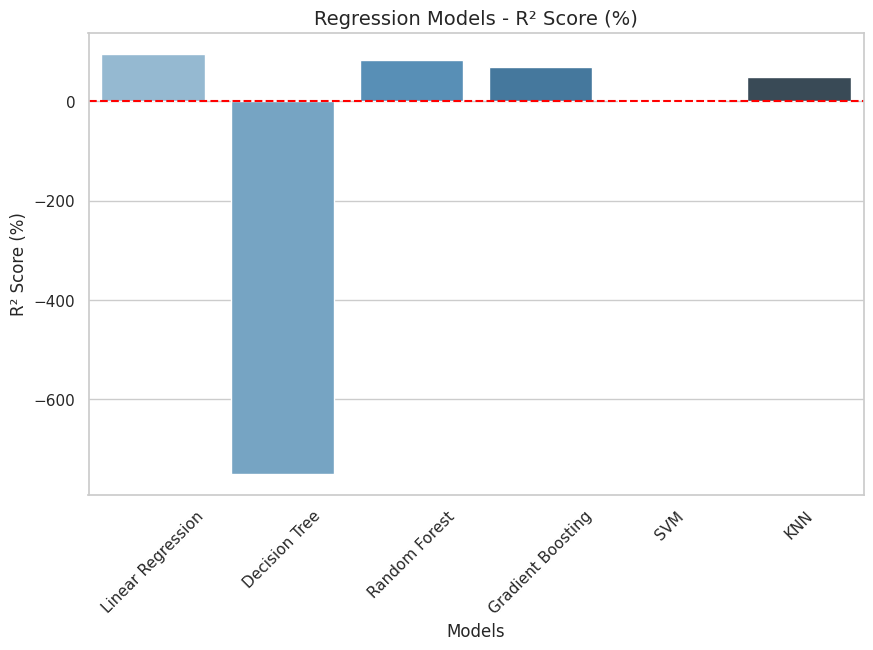

In [32]:
# Results from your run
results = [
    ["Linear Regression", 96.12],
    ["Decision Tree", -750.00],
    ["Random Forest", 83.62],
    ["Gradient Boosting", 68.79],
    ["SVM", -1.73],
    ["KNN", 48.22]
]

# Convert to DataFrame
results_df = pd.DataFrame(results, columns=["Model", "R² (%)"])

# Plot bar chart
plt.figure(figsize=(10,6))
sns.barplot(x="Model", y="R² (%)", data=results_df, palette="Blues_d")

plt.title("Regression Models - R² Score (%)", fontsize=14)
plt.ylabel("R² Score (%)")
plt.xlabel("Models")
plt.xticks(rotation=45)
plt.axhline(0, color="red", linestyle="--")  # mark 0 baseline
plt.show()

## Thank you